# Bài tập tuần 2

## Load Data Set

In [46]:
import seaborn as sns
import pandas as pd
import random
import numpy as np
from scipy.stats import norm
from IPython.display import display  # Thêm dòng này để sửa lỗi
import matplotlib.pyplot as plt
df = sns.load_dataset("iris")
print(df.head())
print(df.shape)
print(df.dtypes)


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


## Phần 1 — Thống kê mô tả & đặc trưng

In [47]:
print("--- 5 DÒNG ĐẦU TIÊN CỦA DATASET ---")
print(df.head())
print("\n" + "="*50 + "\n")
num_rows, num_cols = df.shape
print(f"So cot va hang lan luot la {num_rows,num_cols}")
print("KIỂU DỮ LIỆU CỦA TỪNG CỘT")
print(df.dtypes)

--- 5 DÒNG ĐẦU TIÊN CỦA DATASET ---
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


So cot va hang lan luot la (150, 5)
KIỂU DỮ LIỆU CỦA TỪNG CỘT
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [48]:
num_cols = df.select_dtypes(include=["number"])
summary_dict = {}
for col in num_cols:
    q1 = num_cols[col].quantile(0.25)
    q3 = num_cols[col].quantile(0.75)
    iqr = q3-q1 
    mode_val = num_cols[col].mode()[0]
    summary_dict[col]={"mean": num_cols[col].mean(),
    "median": num_cols[col].median(),
    "mode":mode_val,
    "var" : num_cols[col].var(),
    "std": num_cols[col].std(),
    "min": num_cols[col].min(),
    "max" : num_cols[col].max(),
    "Q1":q1,
    "Q3":q3,
    "IQR": iqr}
df_summary = pd.DataFrame(summary_dict)
print("--- THỐNG KÊ MÔ TẢ CHO MỖI BIẾN SỐ SỐ HỌC ---")
display(df_summary)


--- THỐNG KÊ MÔ TẢ CHO MỖI BIẾN SỐ SỐ HỌC ---


,sepal_length,sepal_width,petal_length,petal_width
mean,5.843333,3.057333,3.758000,1.199333
median,5.800000,3.000000,4.350000,1.300000
mode,5.000000,3.000000,1.400000,0.200000
var,0.685694,0.189979,3.116278,0.581006
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
max,7.900000,4.400000,6.900000,2.500000
Q1,5.100000,2.800000,1.600000,0.300000
Q3,6.400000,3.300000,5.100000,1.800000
IQR,1.300000,0.500000,3.500000,1.500000


In [49]:
grouped_summary = df.groupby('species').agg(['mean', 'std'])

print("--- BẢNG THỐNG KÊ MEAN VÀ STD THEO TỪNG LOÀI ---")
display(grouped_summary)

--- BẢNG THỐNG KÊ MEAN VÀ STD THEO TỪNG LOÀI ---


sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

#### Nhóm khác biệt rõ nhất là loài Setosa. Lý do: Hai đặc trưng về cánh hoa (petal_length và petal_width) của loài setosa có giá trị trung bình nhỏ vượt trội và tách biệt hoàn toàn về mặt không gian đại số so với hai loài còn lại (versicolor và virginica). Trong khi đó, hai loài versicolor và virginica có các chỉ số hình thái khá gần nhau và có sự giao thoa dữ liệu.

## Phần 2 — Phân phối xác suất

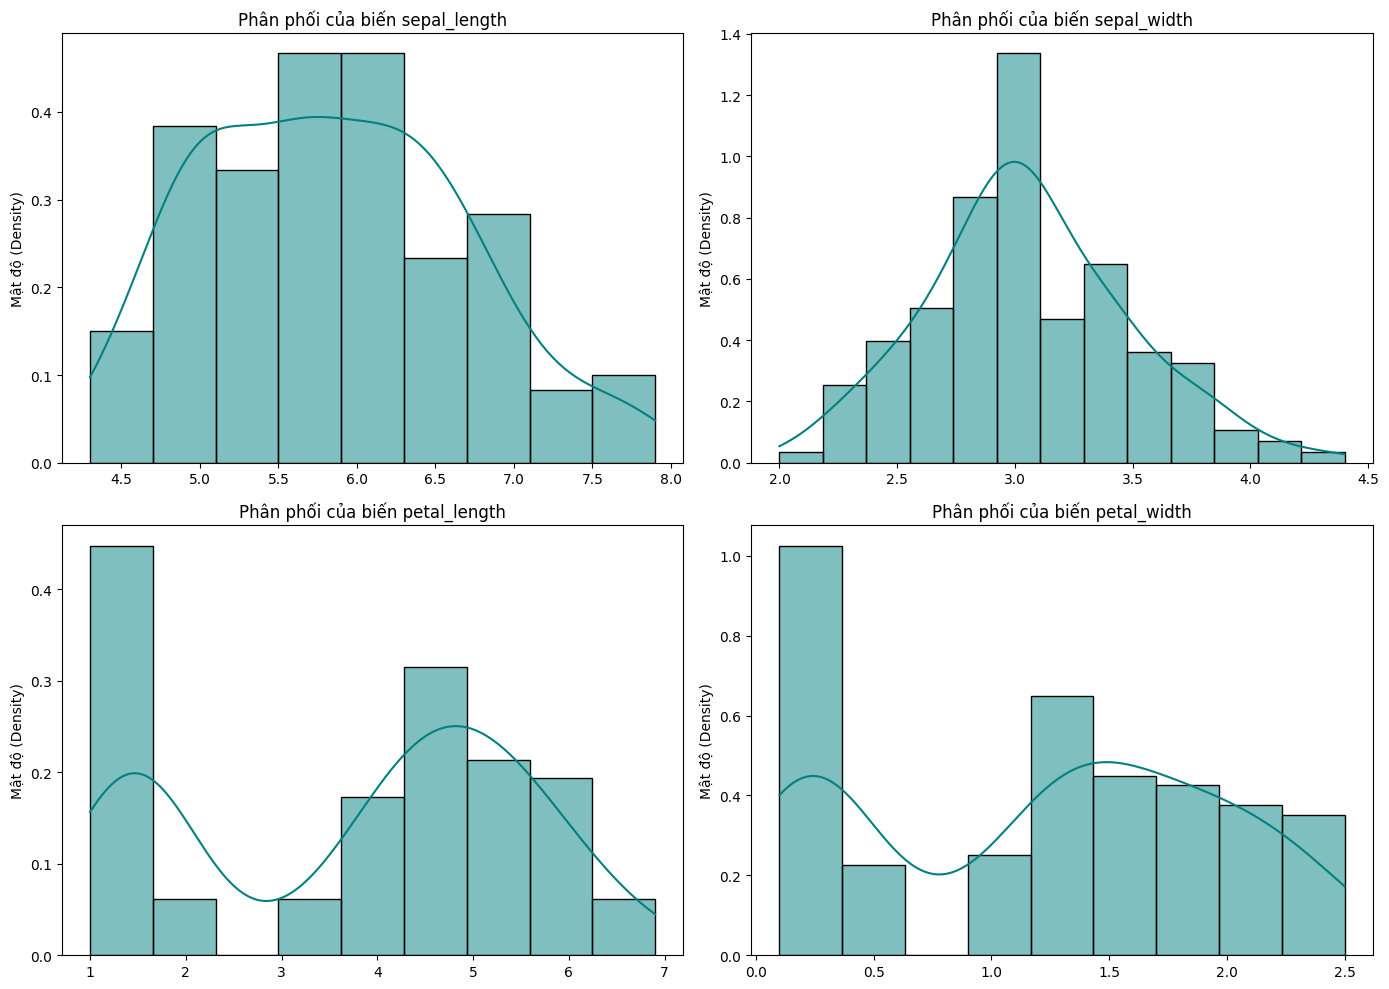

In [50]:
numerical_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
fig,axes = plt.subplots(2,2,figsize=(14,10))
axes = axes.flatten()
for i,col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, stat="density", ax=axes[i], color="teal")
    axes[i].set_title(f"Phân phối của biến {col}", fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Mật độ (Density)")
plt.tight_layout()
plt.show()

**Nhận xét** Phân phối của sepal_length: là phân phối lệch trái nhưng đỉnh phân bố rộng hơn. Phân phối của sepal_width: giống phân phối chuẩn.CÒn phân phối petal_length và petal_width là phân phối có nhiều đỉnh.

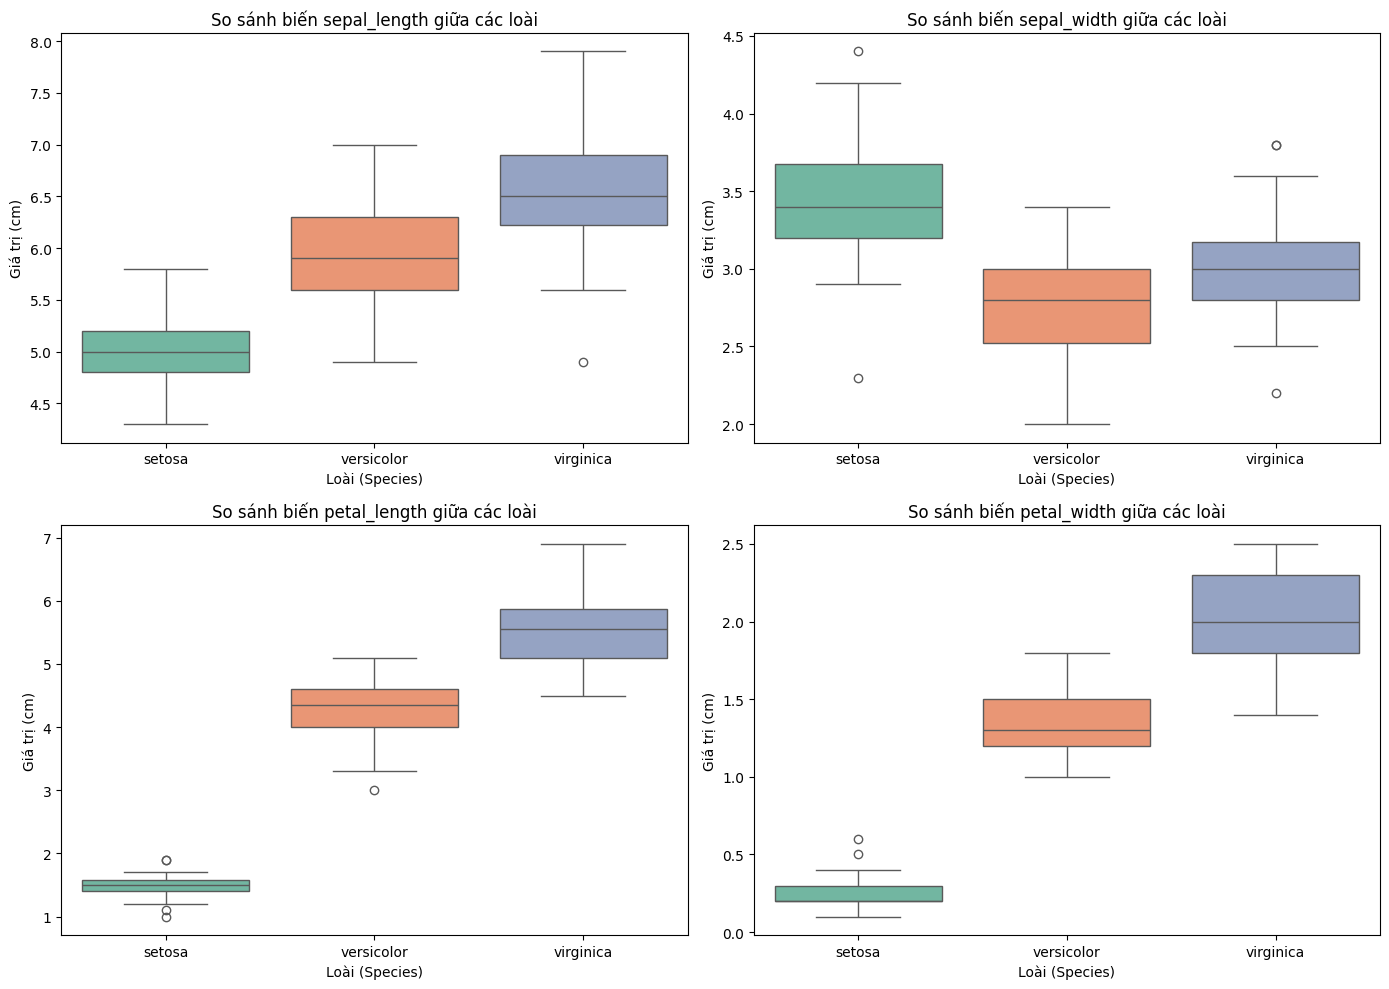

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # Duỗi phẳng ma trận để duyệt tuyến tính

# 3. Vẽ Boxplot cho từng biến số theo nhóm loài (species)
for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x="species", y=col, ax=axes[i], palette="Set2", hue="species", legend=False)
    axes[i].set_title(f"So sánh biến {col} giữa các loài", fontsize=12)
    axes[i].set_xlabel("Loài (Species)")
    axes[i].set_ylabel("Giá trị (cm)")

plt.tight_layout()
plt.show()

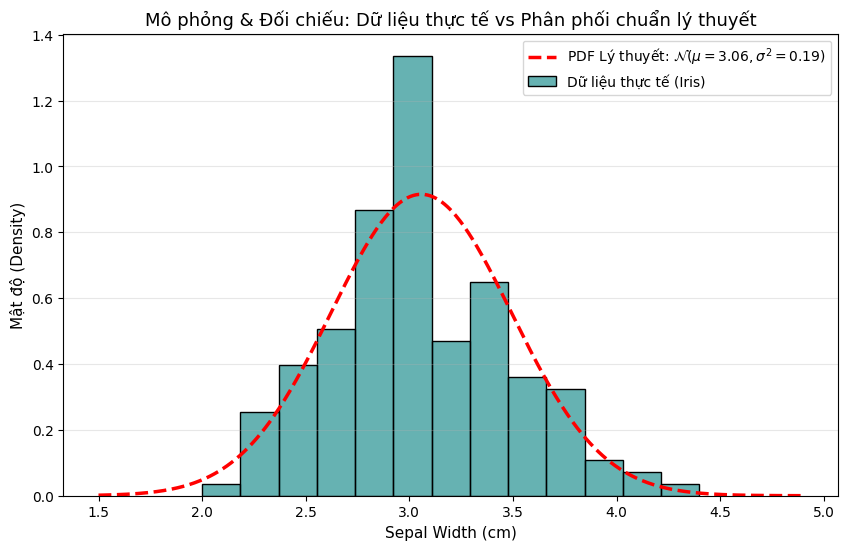

In [ ]:
real_data = df['sepal_width']
mu = real_data.mean()
sigma = real_data.std()

np.random.seed(42)
simulated_data = np.random.normal(loc=mu, scale=sigma, size=10000)

plt.figure(figsize=(10, 6))

sns.histplot(real_data, stat="density", color="teal", alpha=0.6, label="Dữ liệu thực tế (Iris)")
x = np.linspace(real_data.min() - 0.5, real_data.max() + 0.5, 500)
pdf_theoretical = norm.pdf(x, loc=mu, scale=sigma)

plt.plot(x, pdf_theoretical, color="red", linewidth=2.5, linestyle="--", 
         label=f"PDF Lý thuyết: $\mathcal{{N}}(\mu={mu:.2f}, \sigma^2={sigma**2:.2f})$")

plt.title("Mô phỏng & Đối chiếu: Dữ liệu thực tế vs Phân phối chuẩn lý thuyết", fontsize=13)
plt.xlabel("Sepal Width (cm)", fontsize=11)
plt.ylabel("Mật độ (Density)", fontsize=11)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)

plt.show()

**Nhận xét** độ khớp của hàm PDF lý thuyết và dữ liệu thực tế thì nhận thấy nó khá khớp nhau, gần như nó cũng sinh giống như phân phối chuẩn.

## Phần 3 — Phân tích đa biến & tương quan


In [ ]:
numerical_df = df.drop(columns=['species'])
cov_matrix = numerical_df.cov()
corr_matrix = numerical_df.corr()
print("--- MA TRẬN HIỆP PHƯƠNG SAI (COVARIANCE MATRIX) ---")
print(cov_matrix.round(4))
print("\n" + "="*60 + "\n")
print("--- MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX) ---")
print(corr_matrix.round(4))

--- MA TRẬN HIỆP PHƯƠNG SAI (COVARIANCE MATRIX) ---
              sepal_length  sepal_width  petal_length  petal_width
sepal_length        0.6857      -0.0424        1.2743       0.5163
sepal_width        -0.0424       0.1900       -0.3297      -0.1216
petal_length        1.2743      -0.3297        3.1163       1.2956
petal_width         0.5163      -0.1216        1.2956       0.5810


--- MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX) ---
              sepal_length  sepal_width  petal_length  petal_width
sepal_length        1.0000      -0.1176        0.8718       0.8179
sepal_width        -0.1176       1.0000       -0.4284      -0.3661
petal_length        0.8718      -0.4284        1.0000       0.9629
petal_width         0.8179      -0.3661        0.9629       1.0000


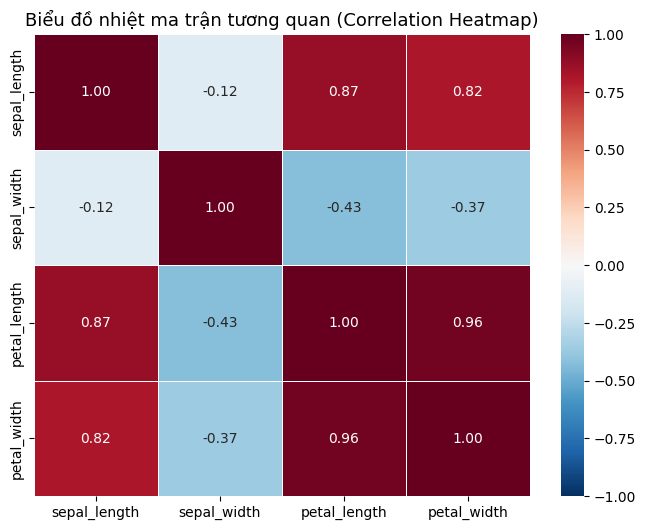

In [55]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix, 
    annot=True,         
    cmap="RdBu_r",      
    vmin=-1, vmax=1,     
    fmt=".2f",           
    linewidths=0.5
)

plt.title("Biểu đồ nhiệt ma trận tương quan (Correlation Heatmap)", fontsize=13)
plt.show()

**Nhận xét** Có đa cộng tuyến mạnh 

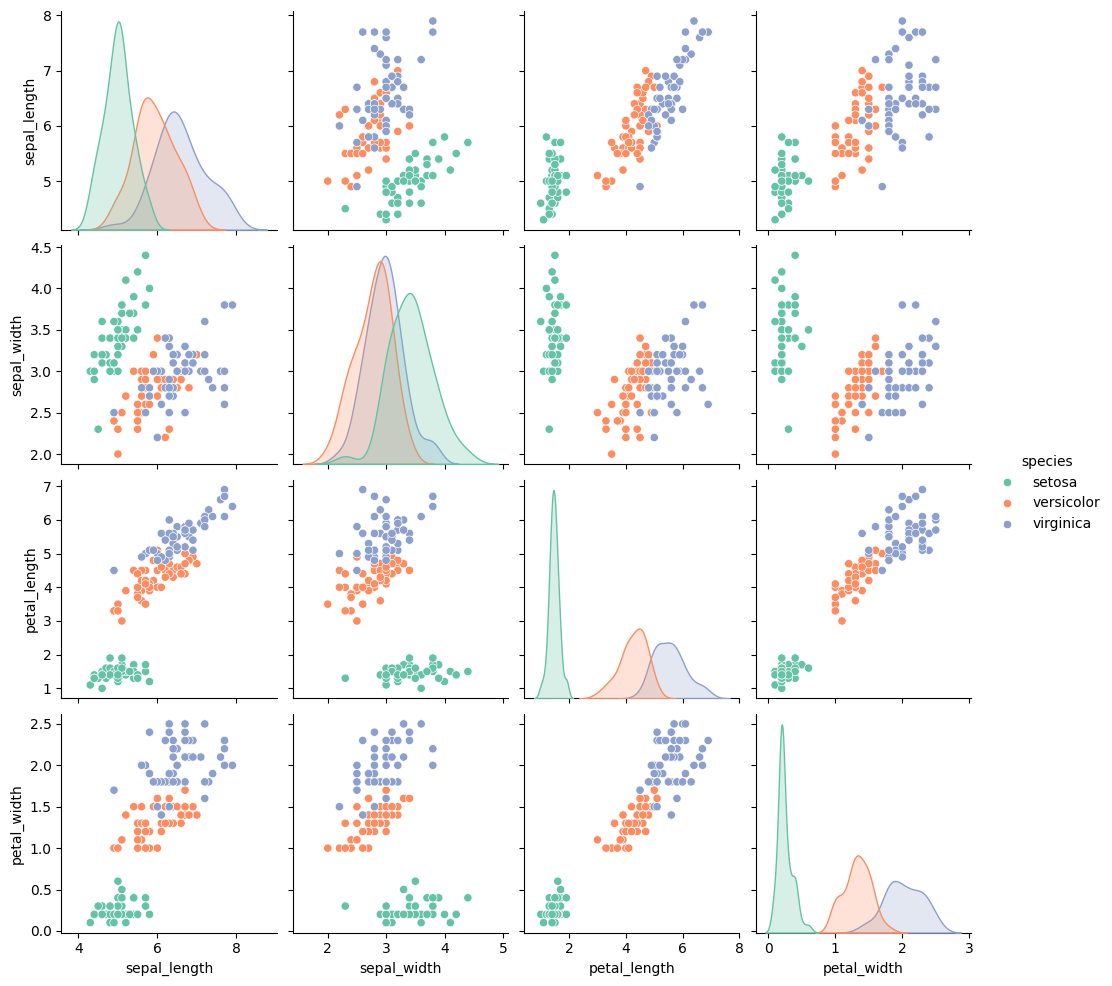

In [ ]:
sns.pairplot(data=df, hue="species", palette="Set2", diag_kind="kde")
plt.show()

**Nhận xét** Loài Setosa: Luôn tạo thành một cụm chấm (cluster) đứng cô lập, tách biệt hoàn toàn khỏi hai loài còn lại trên mọi biểu đồ scatter plot liên quan đến petal_length hoặc petal_width.
Loài Versicolor và Virginica: Các điểm dữ liệu của hai loài này nằm sát nhau và có một vùng giao thoa (overlap) nhẹ ở ranh giới tiếp xúc. Tuy nhiên, chúng vẫn tạo ra hai xu hướng phân cụm có hướng rõ rệt

# Phần 4 — Xác suất & Định lý Bayes

In [57]:
P_B = 0.01        
P_not_B = 1 - P_B 

P_pos_if_B = 0.99 
P_pos_if_not_B = 0.05 

P_positive = (P_pos_if_B * P_B) + (P_pos_if_not_B * P_not_B)

P_B_if_pos = (P_pos_if_B * P_B) / P_positive

print(f"Xác suất toàn phần kết quả dương tính P(+) = {P_positive:.4f}")
print(f"Xác suất thực sự mắc bệnh khi có kết quả dương tính P(B | +) = {P_B_if_pos:.4f}")

Xác suất toàn phần kết quả dương tính P(+) = 0.0594
Xác suất thực sự mắc bệnh khi có kết quả dương tính P(B | +) = 0.1667


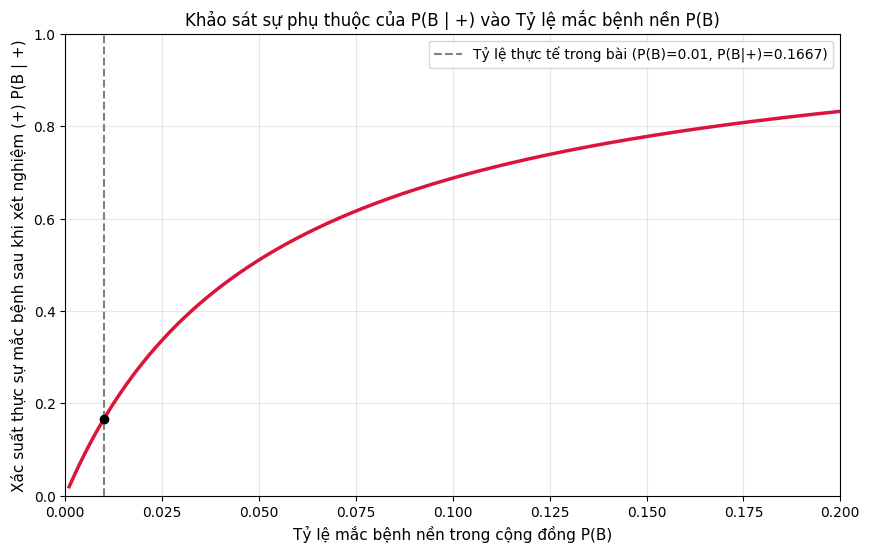

In [ ]:
P_B_range = np.linspace(0.001, 0.2, 1000)

P_positive_range = (P_pos_if_B * P_B_range) + (P_pos_if_not_B * (1 - P_B_range))
P_B_if_pos_range = (P_pos_if_B * P_B_range) / P_positive_range

plt.figure(figsize=(10, 6))
plt.plot(P_B_range, P_B_if_pos_range, color="crimson", linewidth=2.5)
plt.axvline(x=0.01, color="gray", linestyle="--", label="Tỷ lệ thực tế trong bài (P(B)=0.01, P(B|+)=0.1667)")
plt.scatter(0.01, 0.1667, color="black", zorder=5)

plt.title("Khảo sát sự phụ thuộc của P(B | +) vào Tỷ lệ mắc bệnh nền P(B)", fontsize=12)
plt.xlabel("Tỷ lệ mắc bệnh nền trong cộng đồng P(B)", fontsize=11)
plt.ylabel("Xác suất thực sự mắc bệnh sau khi xét nghiệm (+) P(B | +)", fontsize=11)
plt.xlim(0, 0.2)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**Nhận xét** : Nhiều người (kể cả các bác sĩ) thường nhầm tưởng rằng nếu một xét nghiệm có độ chính xác/độ nhạy lên tới $99\%$, thì khi nhận kết quả dương tính, người bệnh có gần $99\%$ cơ hội đã mắc bệnh. Tuy nhiên, kết quả toán học phía trên chỉ ra xác suất thực sự mắc bệnh chỉ vỏn vẹn $16.67\%$. Tức là có tới hơn $83\%$ khả năng họ bị oan (dương tính giả).

In [59]:
import math
P_spam = 0.5
P_ham = 0.5

word_probs = {
    "khuyến_mãi": {"spam": 0.8, "ham": 0.1},
    "trúng_thưởng": {"spam": 0.7, "ham": 0.01},
    "họp":         {"spam": 0.05, "ham": 0.6},
    "báo_cáo":     {"spam": 0.1, "ham": 0.5}
}

def predict_email(email_words):
    score_spam = P_spam
    score_ham = P_ham
    
    for word in email_words:
        if word in word_probs:
            score_spam *= word_probs[word]["spam"]
            score_ham *= word_probs[word]["ham"]
            
    p_spam_given_email = score_spam / (score_spam + score_ham)
    return p_spam_given_email

email_1 = ["khuyến_mãi", "trúng_thưởng"]
email_2 = ["họp", "báo_cáo"]
email_3 = ["khuyến_mãi", "báo_cáo"] # Email hỗn hợp từ khóa

print("--- KẾT QUẢ PHÂN LOẠI EMAIL BẰNG NAIVE BAYES ---")
print(f"Email 1 {email_1} -> Xác suất là Spam: {predict_email(email_1):.4f}")
print(f"Email 2 {email_2} -> Xác suất là Spam: {predict_email(email_2):.4f}")
print(f"Email 3 {email_3} -> Xác suất là Spam: {predict_email(email_3):.4f}")

--- KẾT QUẢ PHÂN LOẠI EMAIL BẰNG NAIVE BAYES ---
Email 1 ['khuyến_mãi', 'trúng_thưởng'] -> Xác suất là Spam: 0.9982
Email 2 ['họp', 'báo_cáo'] -> Xác suất là Spam: 0.0164
Email 3 ['khuyến_mãi', 'báo_cáo'] -> Xác suất là Spam: 0.6154
